In [30]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests

device = torch.accelerator.current_accelerator()
model = Sam3Model.from_pretrained(
    "facebook/sam3",
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
    device_map="auto",
)
model = torch.compile(model)
processor = Sam3Processor.from_pretrained("facebook/sam3")

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [31]:
import numpy as np
import matplotlib
from PIL import ImageDraw, ImageFont

def overlay_masks(image: Image.Image, masks: torch.Tensor):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


def overlay_boxes(image: Image.Image, boxes: torch.Tensor, scores: list):
    image = image.copy().convert("RGBA")
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default(size=24)

    n = len(boxes)
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(max(n, 1))
    colors = [tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(n)]

    for box, score, color in zip(boxes, scores, colors):
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        label = f"{score:.2f}"
        bbox = draw.textbbox((x1, y1 - 28), label, font=font)
        draw.rectangle(bbox, fill=color)
        draw.text((x1, y1 - 28), label, fill="white", font=font)

    return image

In [32]:
def segment_image(image: Image.Image, prompt: str, threshold: float = 0.5, mask_threshold: float = 0.5) -> dict:
    """Segment an image given a text prompt using SAM3.

    Args:
        image: PIL Image to segment.
        prompt: Text description of the object(s) to segment.
        threshold: Confidence threshold for filtering instances.
        mask_threshold: Threshold for binarizing predicted masks.

    Returns:
        Dict with 'masks' (Tensor), 'boxes' (Tensor), and 'scores' (list).
    """
    # Segment using text prompt
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process results
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    return results

Found 2 objects


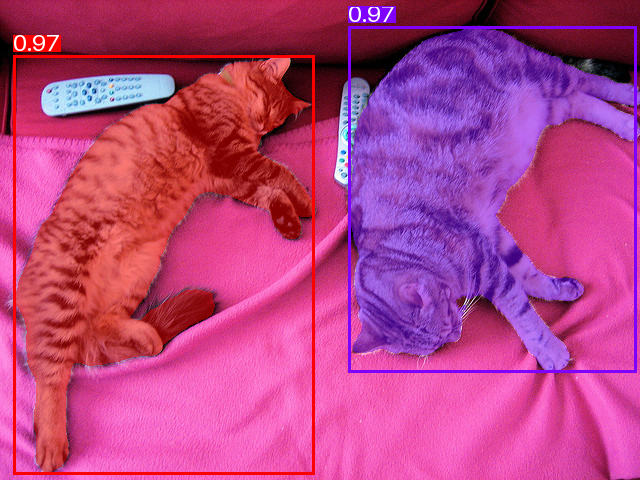

In [33]:
# Load image
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

results = segment_image(image, prompt="cat")
print(f"Found {len(results['masks'])} objects")
result = overlay_masks(image, results["masks"])
result = overlay_boxes(result, results["boxes"], results["scores"])
result

Found 82 objects


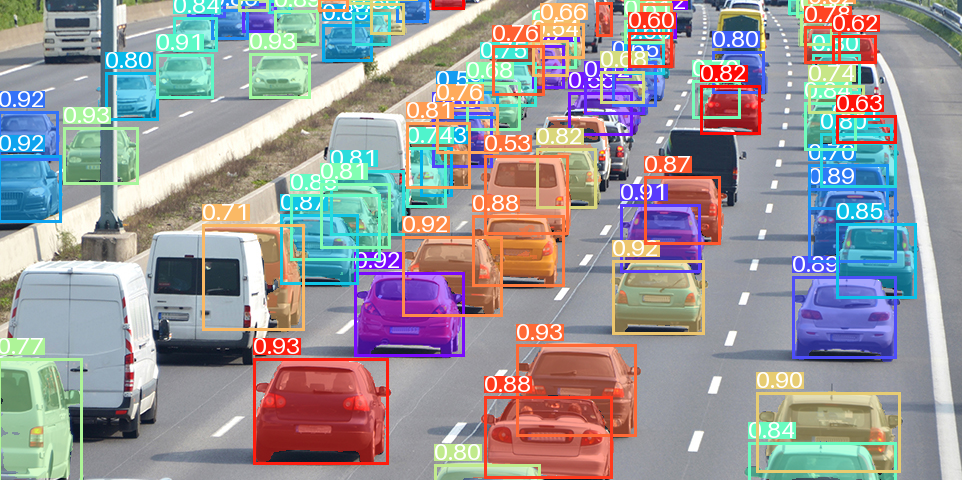

In [34]:
# Load highway image
highway = Image.open("images/highway.jpg").convert("RGB")

results = segment_image(highway, prompt="car")
print(f"Found {len(results['masks'])} objects")
result = overlay_masks(highway, results["masks"])
result = overlay_boxes(result, results["boxes"], results["scores"])
result